<a href="https://colab.research.google.com/github/demsaid400-cpu/DI-BOOTCAMP/blob/main/Week4/Day5/Daily_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [4]:
pokemon = pd.read_csv('/content/pokemon.csv')
combats = pd.read_csv('/content/combats.csv')
tests = pd.read_csv('/content/tests.csv')

print("Data loaded successfully.")
display(pokemon.head())
display(combats.head())
display(tests.head())

Data loaded successfully.


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


,First_pokemon,Second_pokemon
0,129,117
1,660,211
2,706,115
3,195,618
4,27,656


In [6]:
display(pokemon.head())
display(combats.head())
display(tests.head())

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


,First_pokemon,Second_pokemon
0,129,117
1,660,211
2,706,115
3,195,618
4,27,656


In [7]:
pokemon.loc[pokemon["#"] == 62, "Name"] = "Primeape"

In [8]:
pokemon.isnull().sum()

,0
#,0
Name,1
Type 1,0
Type 2,386
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0
Speed,0


In [9]:
wins = combats["Winner"].value_counts()

In [10]:
total_battles = pd.concat([
    combats["First_pokemon"],
    combats["Second_pokemon"]
]).value_counts()

In [11]:
battle_stats = pd.DataFrame({
    "Wins": wins,
    "Battles": total_battles
}).fillna(0)

In [12]:
battle_stats["Win_Percentage"] = (
    battle_stats["Wins"] / battle_stats["Battles"]
) * 100

In [13]:
battle_stats = battle_stats.reset_index()
battle_stats.rename(columns={"index":"#"}, inplace=True)

In [14]:
data = pokemon.merge(
    battle_stats,
    on="#",
    how="left"
)

In [15]:
data["Win_Percentage"] = data["Win_Percentage"].fillna(0)

In [16]:
data.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Wins,Battles,Win_Percentage
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,37.0,133.0,27.819549
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,46.0,121.0,38.016529
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,89.0,132.0,67.424242
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,70.0,125.0,56.000000
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False,55.0,112.0,49.107143


In [17]:
numeric_data = data.select_dtypes(include=np.number)

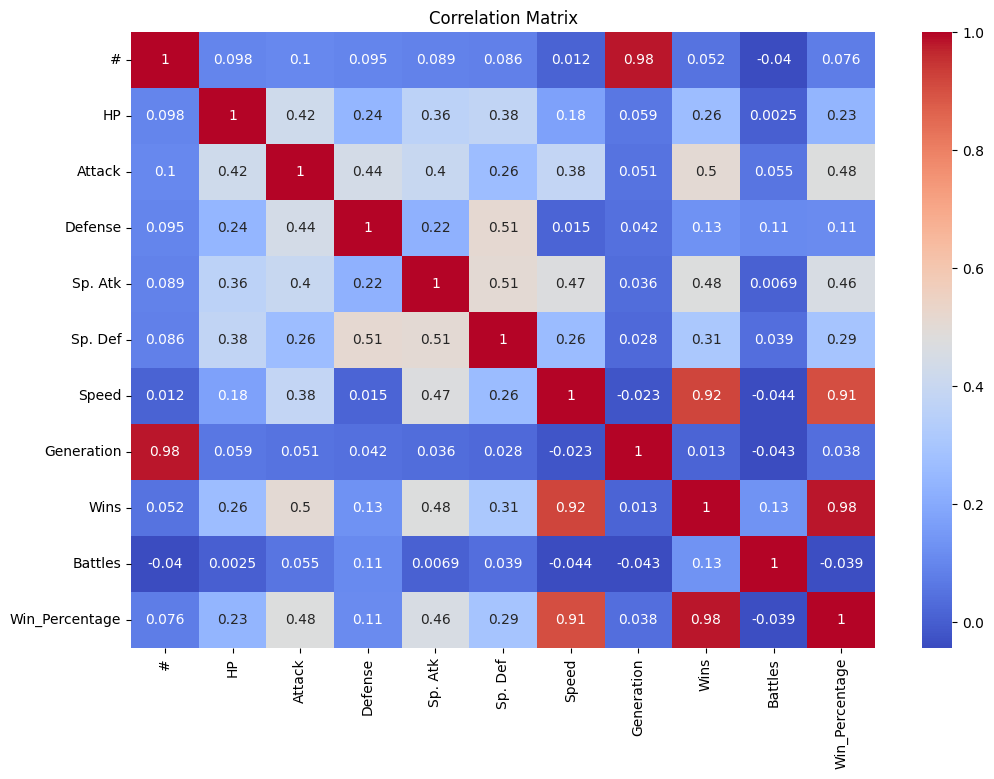

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [19]:
cols = [
    "HP",
    "Attack",
    "Defense",
    "Sp. Atk",
    "Sp. Def",
    "Speed",
    "Win_Percentage"
]

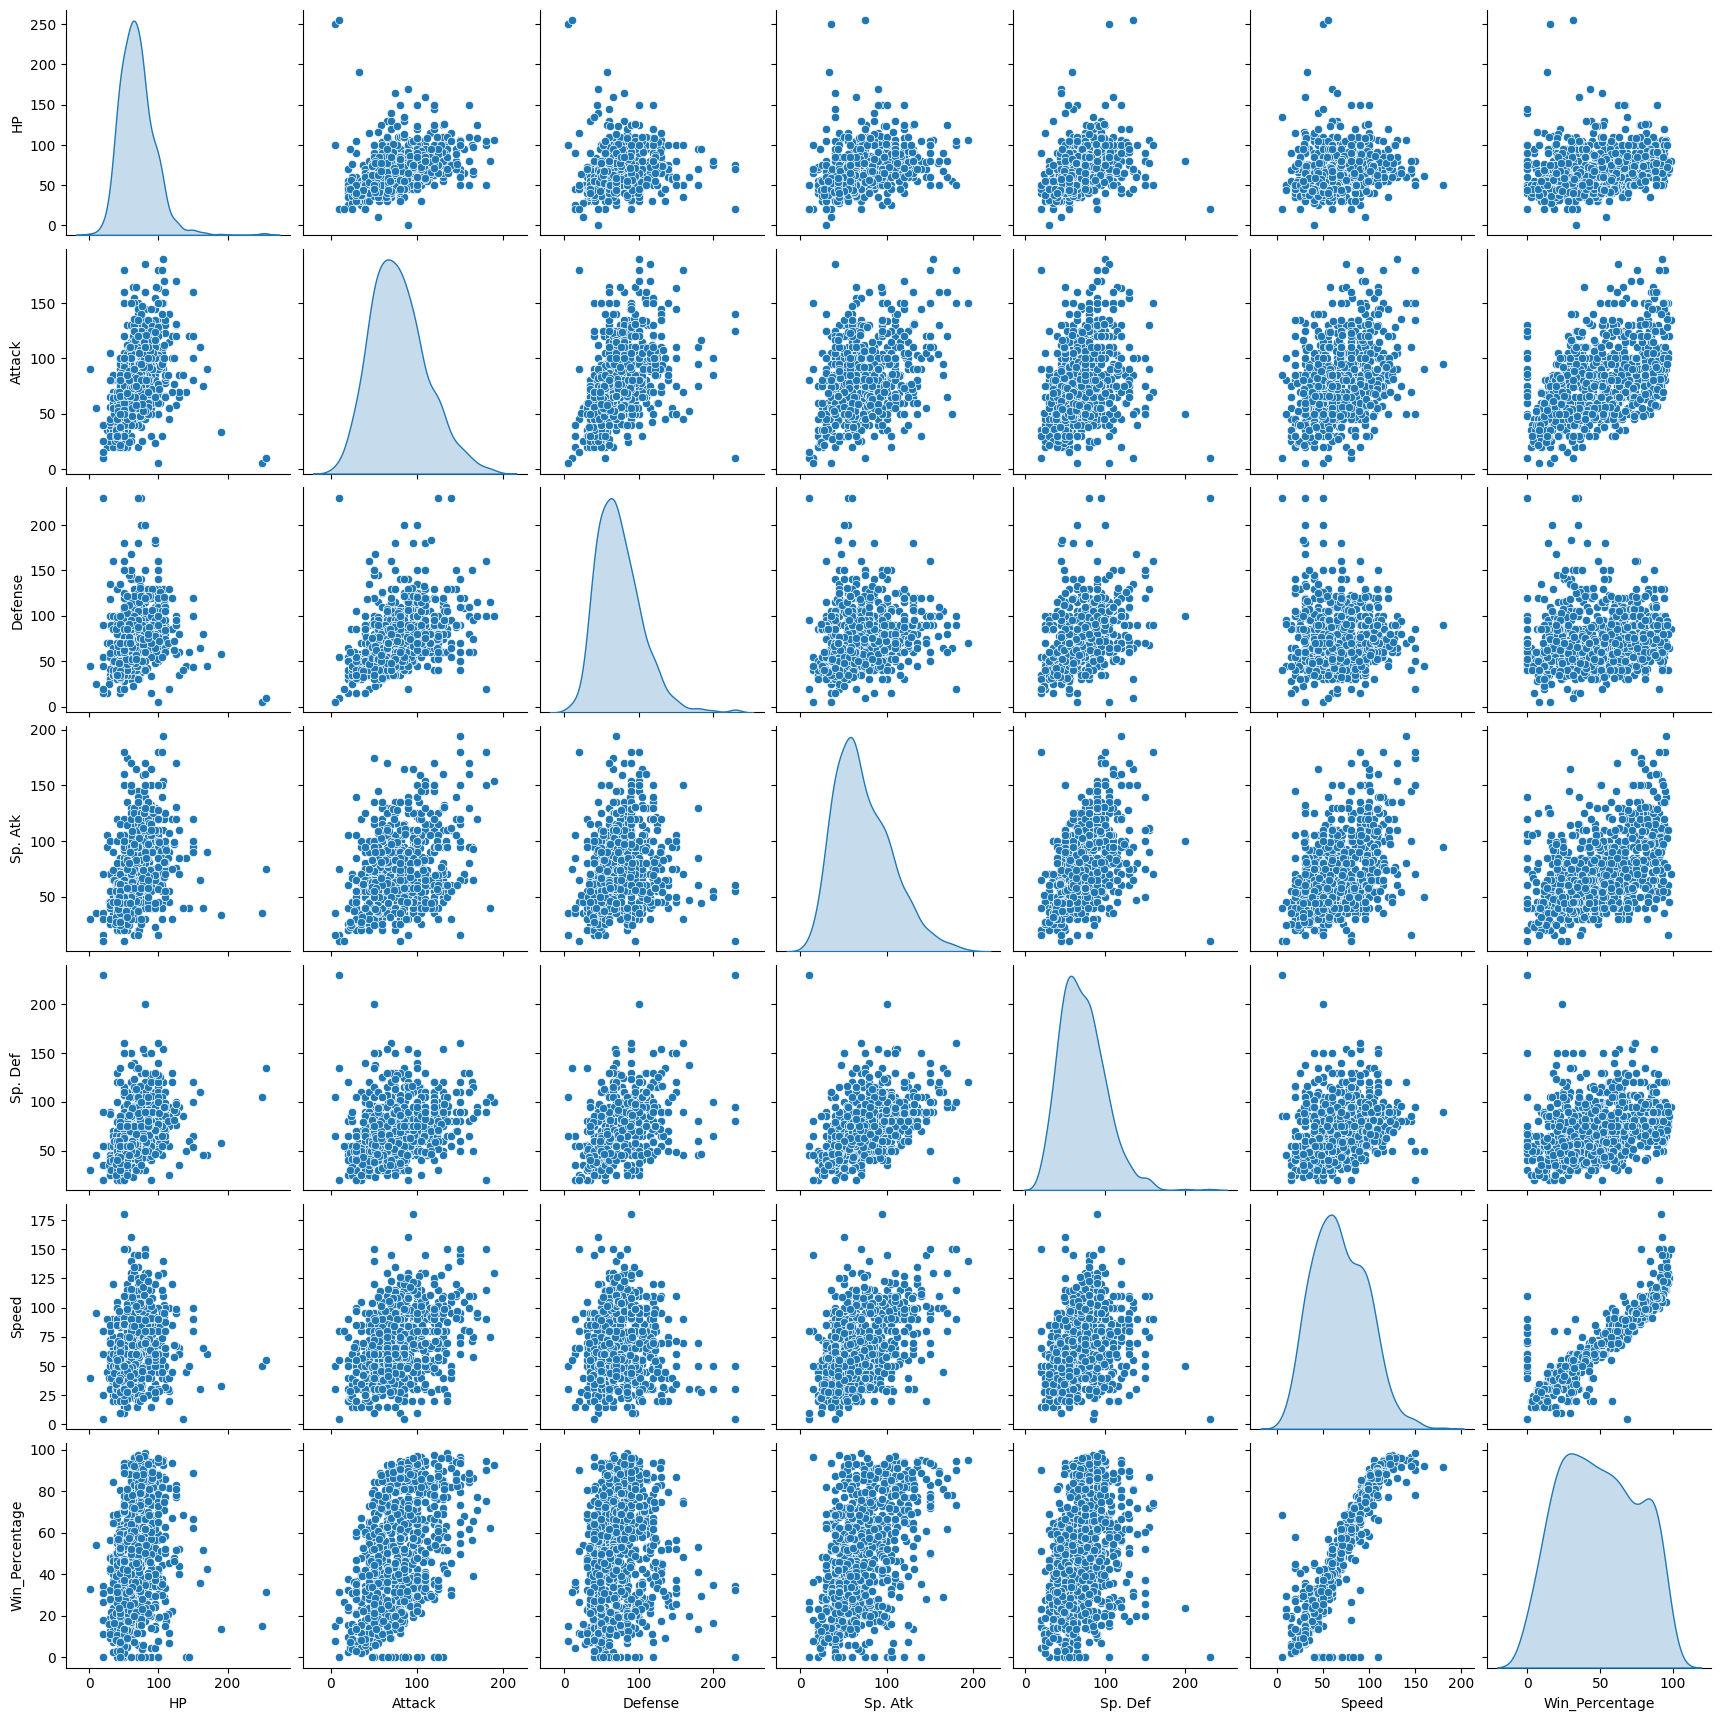

In [20]:
sns.pairplot(
    data[cols],
    diag_kind="kde"
)

plt.show()

In [21]:
top10 = data.sort_values(
    by="Win_Percentage",
    ascending=False
).head(10)

In [22]:
top10[
    [
        "Name",
        "Type 1",
        "HP",
        "Attack",
        "Defense",
        "Speed",
        "Win_Percentage"
    ]
]

,Name,Type 1,HP,Attack,Defense,Speed,Win_Percentage
154,Mega Aerodactyl,Rock,80,135,85,150,98.449612
512,Weavile,Dark,70,120,65,125,97.478992
703,Tornadus Therian Forme,Flying,79,100,80,121,96.800000
19,Mega Beedrill,Bug,65,150,40,145,96.638655
153,Aerodactyl,Rock,80,105,65,130,96.453901
476,Mega Lopunny,Normal,65,136,94,135,96.124031
726,Greninja,Water,72,95,67,122,96.062992
716,Meloetta Pirouette Forme,Normal,100,128,90,128,95.934959
164,Mega Mewtwo Y,Psychic,106,150,70,140,95.200000
349,Mega Sharpedo,Water,70,140,70,105,95.000000


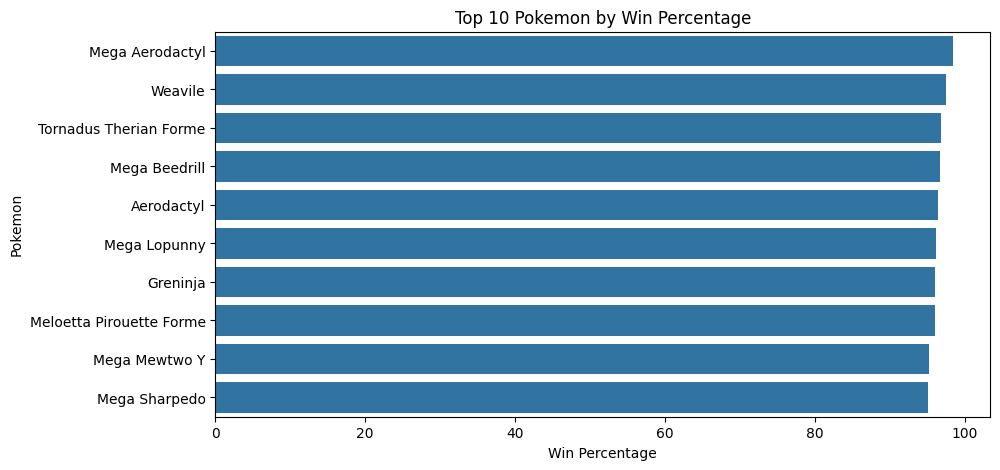

In [23]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Win_Percentage",
    y="Name",
    data=top10
)

plt.title("Top 10 Pokemon by Win Percentage")
plt.xlabel("Win Percentage")
plt.ylabel("Pokemon")

plt.show()

In [24]:
features = [
    "HP",
    "Attack",
    "Defense",
    "Sp. Atk",
    "Sp. Def",
    "Speed",
    "Generation",
    "Legendary"
]

In [25]:
X = data[features]
y = data["Win_Percentage"]

In [26]:
X["Legendary"] = X["Legendary"].astype(int)

/tmp/ipykernel_2008/3914951084.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Legendary"] = X["Legendary"].astype(int)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(
    y_test,
    pred_lr
)

print("Linear Regression MAE:", mae_lr)

Linear Regression MAE: 6.368674750837302


In [29]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(
    y_test,
    pred_rf
)

print("Random Forest MAE:", mae_rf)

Random Forest MAE: 5.705514712348796


In [30]:
gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

mae_gb = mean_absolute_error(
    y_test,
    pred_gb
)

print("Gradient Boosting MAE:", mae_gb)

Gradient Boosting MAE: 5.527185434899662


In [31]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_gb
    ]
})

results.sort_values(
    by="MAE"
)

,Model,MAE
2,Gradient Boosting,5.527185
1,Random Forest,5.705515
0,Linear Regression,6.368675


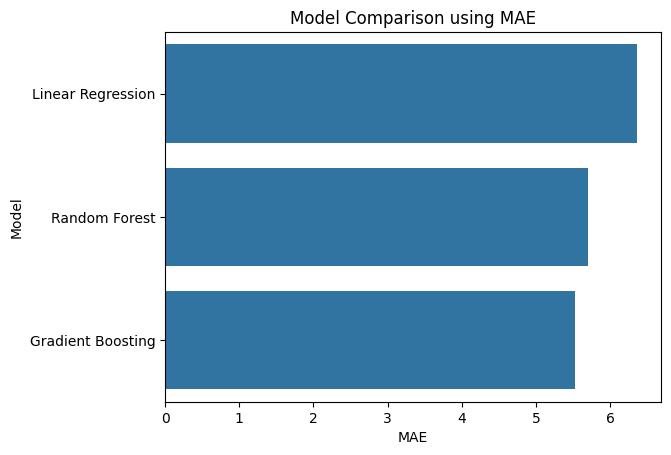

In [32]:
sns.barplot(
    x="MAE",
    y="Model",
    data=results
)

plt.title("Model Comparison using MAE")
plt.show()

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [34]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [35]:
pca = PCA(n_components=2)

components = pca.fit_transform(X_scaled)

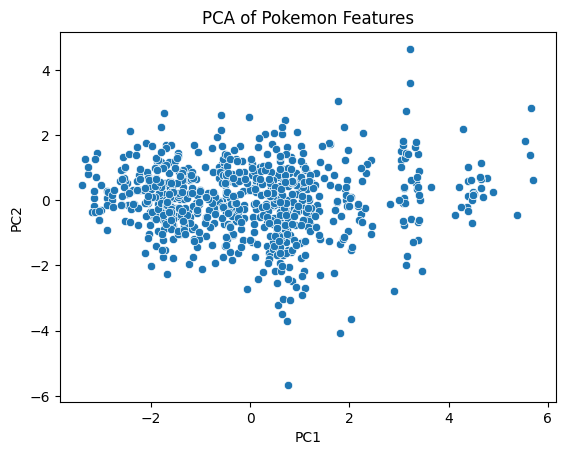

In [36]:
pca_df = pd.DataFrame(
    components,
    columns=["PC1", "PC2"]
)

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2"
)

plt.title("PCA of Pokemon Features")
plt.show()